In [120]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt


In [121]:
df_train = pd.read_csv('train.csv')
df_val = pd.read_csv('val.csv')
df_holdout = pd.read_csv('holdout.csv')

In [122]:
df_train

,ID,REGION,BRANCH,CITY,subject,SUBFRMT,TRADE_SQUARE,HuffFamilies,HuffRelativeFamilies,HOSPITAL,...,FLOORS_TZ,SNT,LOCATION_TYPE,DIST_TO_ADM_CENTER,PARKING,month_count,new_buildings,change_CA,target_1,target_2
0,1,Южный округ,Армавир,Кропоткин,Краснодарский край,2,0.445648,0.019780,0.83,0,...,1,0,3,0.550733,0,318,0,0,175198.181280689,174259.925193
1,2,Южный округ,Новороссийск Запад,Анапа,Краснодарский край,2,0.780890,0.060494,0.83,0,...,1,0,2,1.114666,0,317,0,0,360629.424460479,296286.063051
2,3,Южный округ,Ростов-на-Дону Запад,Таганрог,Ростовская область,2,0.471618,0.033680,0.84,0,...,1,0,2,3.730973,10,315,0,0,252109.534031112,250903.579740
3,4,Кавказский округ,Волгоград Восток,Камышин,Волгоградская область,2,0.555293,0.062644,0.76,0,...,1,0,3,1.039118,15,314,0,0,362653.018943467,351612.980992
4,5,Южный округ,Волгодонск,Волгодонск,Ростовская область,2,0.622970,0.030358,0.93,1,...,1,0,2,1.595111,0,314,0,0,295733.315192993,287970.899275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15104,15105,Сибирский округ,Красноярск,Красноярск,Красноярский край,1,0.419759,0.103733,0.64,0,...,1,0,1,11.306402,0,37,1,0,335833.03570864,335285.135791
15105,15106,Уральский округ,Ноябрьск,Правохеттинский,Ямало-Ненецкий автономный округ,1,0.523817,0.015207,0.48,0,...,1,0,3,0.251115,10,37,0,0,239449.710720112,245862.395965
15106,15107,Южный округ,Волгодонск,Синегорский,Ростовская область,1,0.426907,0.075626,0.54,0,...,1,0,3,1.170235,6,37,0,0,229265.834248059,223720.175478
15107,15108,Южный округ,Ростов-на-Дону Запад,Ростов-на-Дону,Ростовская область,1,0.807060,0.041533,0.93,0,...,1,0,3,6.246047,30,37,0,0,279075.187488385,278484.672897


In [123]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15109 entries, 0 to 15108
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          15109 non-null  int64  
 1   REGION                      15109 non-null  object 
 2   BRANCH                      15109 non-null  object 
 3   CITY                        15109 non-null  object 
 4   subject                     15109 non-null  object 
 5   SUBFRMT                     15109 non-null  int64  
 6   TRADE_SQUARE                15109 non-null  float64
 7   HuffFamilies                15109 non-null  float64
 8   HuffRelativeFamilies        15109 non-null  float64
 9   HOSPITAL                    15109 non-null  int64  
 10  KINDERGARTENS               15109 non-null  int64  
 11  BANKS                       15109 non-null  int64  
 12  MK_ON_MM                    15109 non-null  int64  
 13  ROUTES_CNT                  151

In [124]:
features = df_train.columns.values

In [125]:
features[55]

' target_2 '

In [126]:
df_train[features[54]] = pd.to_numeric(df_train[features[54]], errors='coerce')
df_val[features[54]] = pd.to_numeric(df_val[features[54]], errors='coerce')

In [127]:
features[1:5]

array(['REGION', 'BRANCH', 'CITY', 'subject'], dtype=object)

0:	learn: 0.6613101	test: 0.6614338	best: 0.6614338 (0)	total: 6.14ms	remaining: 6.14s
100:	learn: 0.0042619	test: 0.0042678	best: 0.0042678 (100)	total: 514ms	remaining: 4.58s
200:	learn: 0.0003645	test: 0.0003522	best: 0.0003522 (200)	total: 1.01s	remaining: 4s
300:	learn: 0.0001274	test: 0.0001186	best: 0.0001186 (300)	total: 1.49s	remaining: 3.47s
400:	learn: 0.0000907	test: 0.0000831	best: 0.0000831 (399)	total: 2s	remaining: 2.99s
500:	learn: 0.0000885	test: 0.0000809	best: 0.0000809 (500)	total: 2.44s	remaining: 2.43s
600:	learn: 0.0000869	test: 0.0000794	best: 0.0000794 (600)	total: 2.9s	remaining: 1.93s
700:	learn: 0.0000852	test: 0.0000778	best: 0.0000778 (700)	total: 3.33s	remaining: 1.42s
800:	learn: 0.0000846	test: 0.0000772	best: 0.0000772 (798)	total: 3.79s	remaining: 940ms
900:	learn: 0.0000841	test: 0.0000767	best: 0.0000767 (900)	total: 4.17s	remaining: 458ms
999:	learn: 0.0000840	test: 0.0000767	best: 0.0000767 (999)	total: 4.55s	remaining: 0us

bestTest = 7.66651369

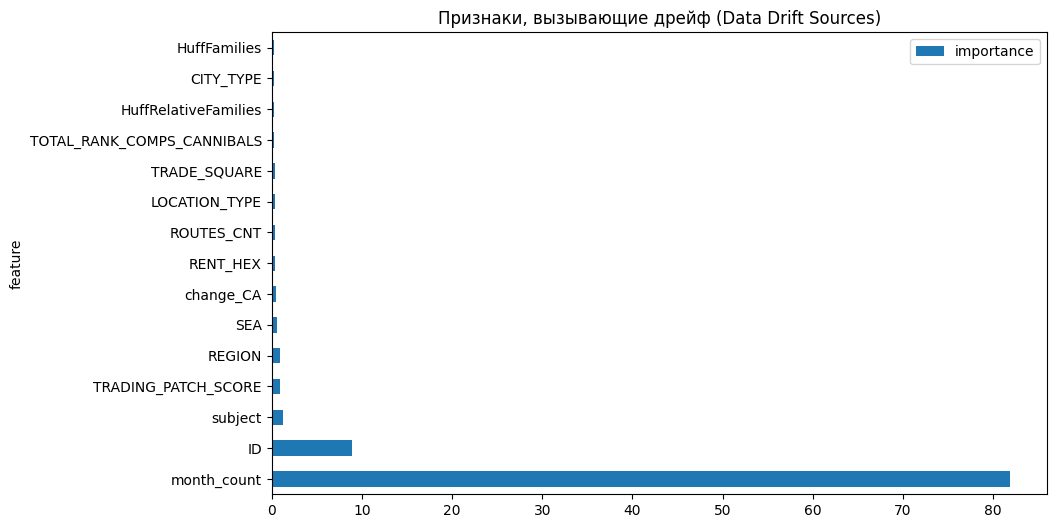

In [128]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

old_data = pd.concat([train, val], axis=0).reset_index(drop=True)
old_data['is_holdout'] = 0
new_data = holdout.copy()
new_data['is_holdout'] = 1
df_adv = pd.concat([old_data, new_data], axis=0).reset_index(drop=True)

features_to_drop = [features[54], features[55], 'is_holdout']
X = df_adv.drop(columns=[col for col in features_to_drop if col in df_adv.columns])
y = df_adv['is_holdout']

cat_features = features[1:5]

cat_features = [c for c in cat_features if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"\nROC-AUC Adversarial Validation: {auc:.4f}")

if auc > 0.7:
    print("ВНИМАНИЕ: Наблюдается значительный дрейф данных!")
else:
    print("Дрейф данных умеренный.")


importances = model.get_feature_importance(type='FeatureImportance')
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nТоп признаков, по которым holdout отличается от train/val:")
print(feature_importance_df.head(10))

feature_importance_df.head(15).plot(kind='barh', x='feature', y='importance', figsize=(10, 6))
plt.title('Признаки, вызывающие дрейф (Data Drift Sources)')
plt.show()

<Axes: >

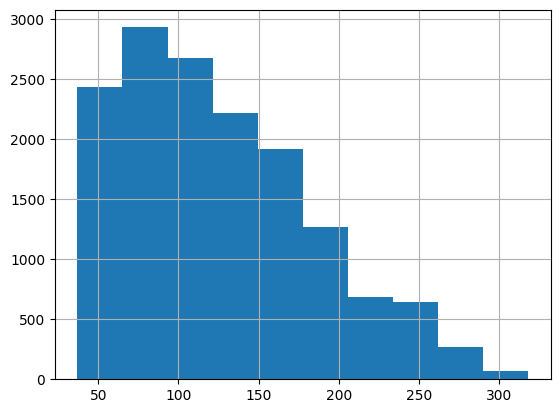

In [129]:
df_train['month_count'].hist()

<Axes: >

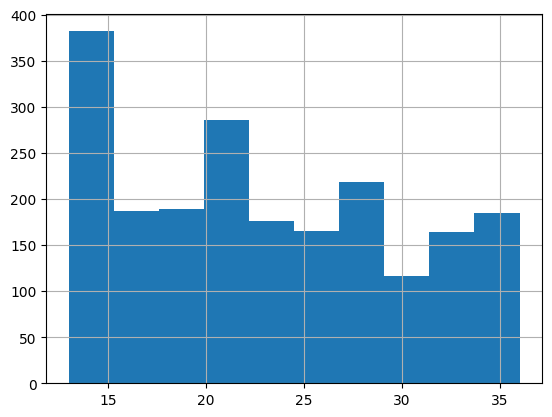

In [130]:
df_val['month_count'].hist()

<Axes: >

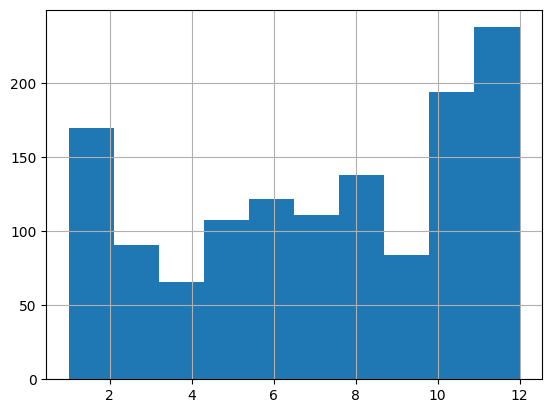

In [131]:
df_holdout['month_count'].hist()

УДАЛЯЕМ ID и MOUNT_COUNT 

Ого! ROC-AUC 1.0000 — это "идеальное" разделение. Это значит, что данные в holdout (будущие магазины) критически отличаются от тех, что у вас в обучении. Если вы просто обучите модель сейчас, она может выдать на холдоуте случайные числа.
Давайте "препарировать" ваш результат и исправлять ситуацию:
1. Самый важный враг: ID (importance 8.94)
Что произошло: Модель увидела, что в train айдишники, например, от 1 до 5000, а в holdout — от 5001 до 6000. Она просто запомнила порядковый номер.
Что делать: Немедленно удалите ID из всех обучающих выборок. Он не несет физического смысла для продаж, но создает "утечку" (leakage), по которой классификатор легко разделяет выборки.
2. Главный источник дрейфа: month_count (importance 81.83)
Это ваш "киллер" качества.
Почему так: В train и val у вас уже работающие магазины, у них month_count может быть 12, 24, 60 месяцев. А holdout — это точки, которые только планируются к открытию. Скорее всего, там month_count либо равен 0, либо 1, либо вообще пропущен.
Проблема: Если вы оставите этот признак, модель регрессии "привыкнет", что высокие продажи бывают только при month_count > 12. Когда она увидит 0 в холдоуте, она может предсказать мизерные продажи или вообще сломаться.
Что делать:
Посмотрите распределение month_count в train и holdout. Если в holdout всегда одно и то же число (например, 0), то этот признак бесполезен для прогноза будущих продаж.
Решение: Удалите month_count из признаков для обучения регрессии. Мы должны прогнозировать продажи "на старте" или "целевой уровень", независимо от того, сколько месяцев магазин уже отработал в обучающей выборке.
3. Географический и инфраструктурный дрейф (subject, REGION, RENT_HEX)
Тут дрейф "честный". Видимо, компания начала открывать магазины в новых регионах или в местах с другой стоимостью аренды.


0:	learn: 0.6706107	test: 0.6709622	best: 0.6709622 (0)	total: 5.83ms	remaining: 5.82s
100:	learn: 0.2152157	test: 0.2171073	best: 0.2171073 (100)	total: 518ms	remaining: 4.61s
200:	learn: 0.1739603	test: 0.1767821	best: 0.1767821 (200)	total: 1.1s	remaining: 4.36s
300:	learn: 0.1629590	test: 0.1677991	best: 0.1677991 (300)	total: 1.71s	remaining: 3.97s
400:	learn: 0.1559882	test: 0.1631386	best: 0.1631386 (400)	total: 2.34s	remaining: 3.5s
500:	learn: 0.1512357	test: 0.1604286	best: 0.1604286 (500)	total: 2.95s	remaining: 2.94s
600:	learn: 0.1474632	test: 0.1583346	best: 0.1583346 (600)	total: 3.58s	remaining: 2.37s
700:	learn: 0.1445072	test: 0.1569975	best: 0.1569975 (700)	total: 4.16s	remaining: 1.77s
800:	learn: 0.1418706	test: 0.1559018	best: 0.1559018 (800)	total: 4.71s	remaining: 1.17s
900:	learn: 0.1393741	test: 0.1549720	best: 0.1549720 (900)	total: 5.26s	remaining: 578ms
999:	learn: 0.1369339	test: 0.1542105	best: 0.1542105 (999)	total: 5.83s	remaining: 0us

bestTest = 0.154

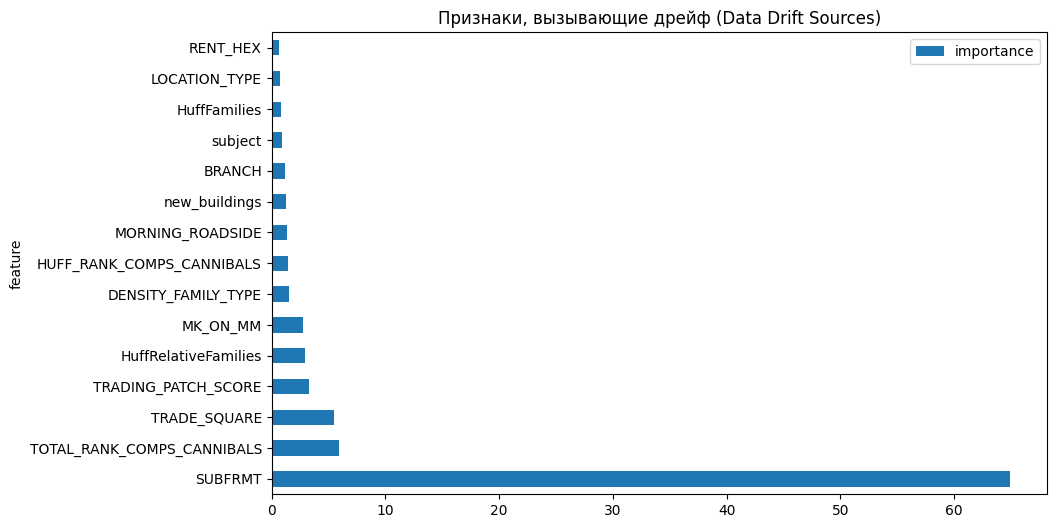

In [132]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

old_data = pd.concat([train, val], axis=0).reset_index(drop=True)
old_data['is_holdout'] = 0
new_data = holdout.copy()
new_data['is_holdout'] = 1
df_adv = pd.concat([old_data, new_data], axis=0).reset_index(drop=True)

features_to_drop = [features[0],features[54], features[55], 'month_count', 'is_holdout']
X = df_adv.drop(columns=[col for col in features_to_drop if col in df_adv.columns])
y = df_adv['is_holdout']

cat_features = features[1:5]

cat_features = [c for c in cat_features if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"\nROC-AUC Adversarial Validation: {auc:.4f}")

if auc > 0.7:
    print("ВНИМАНИЕ: Наблюдается значительный дрейф данных!")
else:
    print("Дрейф данных умеренный.")


importances = model.get_feature_importance(type='FeatureImportance')
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nТоп признаков, по которым holdout отличается от train/val:")
print(feature_importance_df.head(10))

feature_importance_df.head(15).plot(kind='barh', x='feature', y='importance', figsize=(10, 6))
plt.title('Признаки, вызывающие дрейф (Data Drift Sources)')
plt.show()

Ситуация прояснилась. ROC-AUC **0.93** после удаления технических полей — это всё еще очень много. Но теперь мы видим «мясо» проблемы.

Главный виновник дрейфа — **`SUBFRMT` (65% важности!)**. 

### 1. Что не так с `SUBFRMT`?
Такая огромная важность означает одно из двух:
*   **Сценарий А:** В `holdout` появились новые форматы магазинов, которых вообще не было в `train`.
*   **Сценарий Б:** В `train` было, скажем, 80% "магазинов у дома" и 20% "супермаркетов", а в `holdout` пропорция стала 10/90.

**Что нужно сделать прямо сейчас:**
Выполните этот код, чтобы понять масштаб беды:
```python
print("Train SUBFRMT counts:\n", train['SUBFRMT'].value_counts(normalize=True))
print("\nHoldout SUBFRMT counts:\n", holdout['SUBFRMT'].value_counts(normalize=True))
```
**Если в холдоуте есть форматы, которых нет в трейне:** Модель на них «галлюцинирует». Вам придется либо объединять редкие форматы в группу "Other", либо искать максимально похожий формат в трейне и переименовывать их.

---

### 2. Анализ остальных признаков дрейфа
*   **`TOTAL_RANK_COMPS_CANNIBALS` и `HUFF_RANK_COMPS_CANNIBALS`:** Это подтверждает слова из описания задачи — "новые точки открываются в насыщенных зонах". У новых магазинов в холдоуте ранг конкуренции и каннибализации выше, чем у старых. Модель в трейне привыкла к "легким" условиям, а в холдоуте — "жесть".
*   **`TRADE_SQUARE`:** Похоже, компания сменила стратегию по площади магазинов (они стали либо сильно меньше, либо сильно больше).

---

### 3. СТРАТЕГИЯ ПОБЕДЫ (Как строить модель при таком дрейфе)

Чтобы ваша модель не «развалилась» через квартал, используйте следующие подходы:

#### А. Sample Weighting (Взвешивание выборки) — Самый мощный метод
Раз `holdout` так сильно отличается, давайте заставим модель при обучении на `train` больше доверять тем строкам, которые **похожи** на `holdout`.

1.  Возьмите вероятности (`preds_proba`) из вашего последнего классификатора (Adversarial Validation) для выборки `train`.
2.  Рассчитайте веса: `weights = preds_proba / (1 - preds_proba)`.
3.  Обучайте регрессор CatBoost с этими весами:
```python
model_reg = CatBoostRegressor(loss_function='MAPE')
model_reg.fit(X_train, y_train, sample_weight=train_weights)
```
*Это заставит модель выучить зависимости, характерные для "новых" условий рынка.*

#### Б. Обработка `SUBFRMT`
Если `SUBFRMT` так сильно влияет на дрейф, попробуйте сделать **Target Encoding** для него, но с сильным сглаживанием (smoothing), или используйте `CatBoost`, но проверьте, чтобы в `val` и `train` были одни и те же категории.

#### В. Создание относительных признаков (Feature Engineering)
Вместо абсолютных значений, которые дрейфуют, используйте относительные:
*   `Families_per_Square` = `HuffFamilies / TRADE_SQUARE`
*   `Relative_Competition` = `HUFF_RANK_COMPS_CANNIBALS / TOTAL_RANK_COMPS_CANNIBALS`
*   Отношение площади магазина к средней площади в этом `REGION`.

#### Г. Валидация "под холдоут"
Вместо случайного разбиения на `train` и `val`, попробуйте отобрать в `val` те магазины из имеющихся данных, которые ваш классификатор пометил как "похожие на холдоут" (с самой высокой вероятностью `is_holdout`). Это даст вам **честный MAPE**, который вы реально увидите на лидерборде.

---

### Итоговый план действий для регрессии:
1.  **Таргет:** Используйте `np.log1p(train['TARGET_2'])` как целевую переменную (не забудьте потом сделать `np.expm1` для прогноза). Это часто помогает при MAPE.
2.  **Признаки:** 
    *   Удалите `ID`, `month_count`.
    *   Оставьте `SUBFRMT`, но следите за новыми категориями.
    *   Добавьте веса объектов (Sample Weights), как описано выше.
3.  **Модель:** CatBoostRegressor.
    *   `loss_function='MAPE'`
    *   `eval_metric='MAPE'`
    *   `early_stopping_rounds=100`
4.  **Стабильность:** Обучите 5 моделей с разными `random_seed` и усредните их предсказания. Это защитит от переобучения под конкретные признаки дрейфа.

**Что из этого попробуем внедрить первым?** Советую начать с проверки частот `SUBFRMT` и обучения регрессии с весами.

In [133]:
print("Train SUBFRMT counts:\n", train['SUBFRMT'].value_counts(normalize=True))
print("\nHoldout SUBFRMT counts:\n", holdout['SUBFRMT'].value_counts(normalize=True))

Train SUBFRMT counts:
 SUBFRMT
2    0.595341
1    0.404659
Name: proportion, dtype: float64

Holdout SUBFRMT counts:
 SUBFRMT
1    1.0
Name: proportion, dtype: float64


In [134]:
val['SUBFRMT'].value_counts(normalize=True)

SUBFRMT
1    0.990329
2    0.009671
Name: proportion, dtype: float64

Это критическое открытие! Теперь понятно, почему ROC-AUC был 0.93. 

**Суть проблемы:** В `holdout` (вашем будущем) компания открывает магазины **только формата «1»**. При этом в `train` 60% данных — это формат «2». 

Если вы оставите всё как есть, модель будет пытаться «усреднить» паттерны обоих форматов. Но формат «2» может иметь совсем другую площадь, логистику и средний чек. Обучаться на нем для прогноза формата «1» — это всё равно что учиться водить грузовик (формат 2), чтобы потом пересесть на легковую машину (формат 1).

### Что делать с `SUBFRMT`? (3 стратегии)

#### Стратегия №1: Радикальная (Рекомендуется для чистоты)
Поскольку в холдоуте **только формат 1**, вы можете **отфильтровать `train` и `val`**, оставив в них только строки с `SUBFRMT == 1`.
*   **Плюс:** Модель будет идеально заточена под нужный формат. Никакого шума от другого типа магазинов.
*   **Минус:** Вы потеряете 60% данных.
*   **Когда применять:** Если после удаления формата «2» у вас остается хотя бы 1000–2000 строк в `train`.

#### Стратегия №2: Мягкая (Взвешивание)
Используйте все данные, но дайте формату «1» огромный вес, а формату «2» — маленький. 
Но есть способ лучше: если вы используете **Sample Weighting** на основе Adversarial Validation (как я писал выше), модель **сама автоматически** обнулит или сильно занизит веса для формата «2», потому что его нет в холдоуте.

#### Стратегия №3: Трансформация признака
Если данных мало и формат «2» выкидывать жалко:
1.  Удалите колонку `SUBFRMT` из обучения (она всё равно константа в холдоуте и только путает модель).
2.  Оставьте данные обоих форматов, но добавьте признаки, которые их «уравнивают» (например, продажи на 1 кв. м., `TARGET / TRADE_SQUARE`).

---

### План действий №2 (Обновленный):

1.  **Создайте "Чистый Трейт":**
    ```python
    # Оставляем только те форматы, которые есть в будущем
    train_filtered = train[train['SUBFRMT'] == 1].copy()
    val_filtered = val[val['SUBFRMT'] == 1].copy()
    ```
2.  **Запустите Adversarial Validation еще раз** на `train_filtered` vs `holdout`.
    *   *Зачем:* Чтобы увидеть, какие признаки дрейфуют **внутри** формата «1». Теперь, когда `SUBFRMT` перестал «кричать» о дрейфе, вы увидите настоящие изменения (например, в площади или конкурентах).
3.  **Обучите регрессию на отфильтрованных данных:**
    ```python
    model_reg = CatBoostRegressor(loss_function='MAPE', eval_metric='MAPE')
    model_reg.fit(
        train_filtered[features], train_filtered['TARGET_2'],
        eval_set=(val_filtered[features], val_filtered['TARGET_2'])
    )
    ```

### Почему ROC-AUC всё еще 0.93?
Даже если вы отфильтруете `SUBFRMT`, ROC-AUC может остаться высоким. Посмотрите на ваши прошлые результаты: там был признак `TOTAL_RANK_COMPS_CANNIBALS` и `TRADE_SQUARE`. 
Это значит, что магазины формата «1» в будущем (holdout) стали:
*   Другого размера (площадь).
*   Открываться в местах с более жесткой конкуренцией.

**Ваша задача — заставить модель выучить эти новые условия.**

**Попробуйте сейчас:**
1. Отфильтровать `train` и `val`, оставив только `SUBFRMT == 1`.
2. Снова запустить Adversarial Validation (без ID и month_count).
3. Напишите сюда топ-5 признаков. Это будут "финальные боссы" дрейфа, с которыми нам нужно будет поработать через создание новых признаков (Feature Engineering).

0:	learn: 0.6819723	test: 0.6819455	best: 0.6819455 (0)	total: 5.42ms	remaining: 5.41s
100:	learn: 0.2618652	test: 0.2625300	best: 0.2625300 (100)	total: 523ms	remaining: 4.66s
200:	learn: 0.2112504	test: 0.2136575	best: 0.2136575 (200)	total: 1.08s	remaining: 4.28s
300:	learn: 0.1954608	test: 0.2002227	best: 0.2002227 (300)	total: 1.67s	remaining: 3.89s
400:	learn: 0.1863974	test: 0.1935886	best: 0.1935886 (400)	total: 2.25s	remaining: 3.36s
500:	learn: 0.1803659	test: 0.1894783	best: 0.1894783 (500)	total: 2.81s	remaining: 2.79s
600:	learn: 0.1756275	test: 0.1867533	best: 0.1867533 (600)	total: 3.38s	remaining: 2.24s
700:	learn: 0.1720542	test: 0.1847781	best: 0.1847781 (700)	total: 3.93s	remaining: 1.68s
800:	learn: 0.1692271	test: 0.1833669	best: 0.1833669 (800)	total: 4.46s	remaining: 1.11s
900:	learn: 0.1662824	test: 0.1819769	best: 0.1819769 (900)	total: 5.01s	remaining: 550ms
999:	learn: 0.1633020	test: 0.1809123	best: 0.1809123 (999)	total: 5.57s	remaining: 0us

bestTest = 0.1

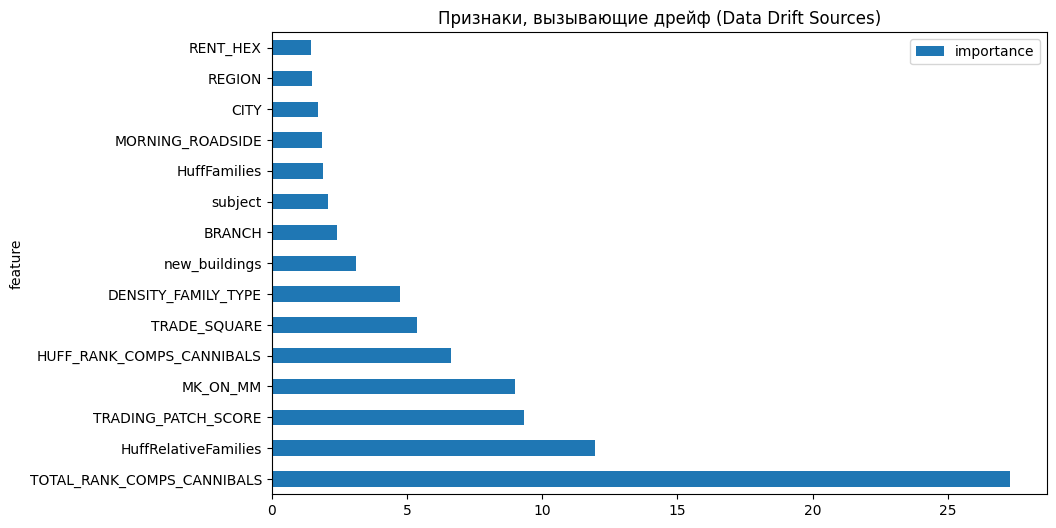

In [135]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

old_data = pd.concat([train, val], axis=0).reset_index(drop=True)
old_data['is_holdout'] = 0
new_data = holdout.copy()
new_data['is_holdout'] = 1
df_adv = pd.concat([old_data, new_data], axis=0).reset_index(drop=True)

df_adv['DIST_TO_ADM_CENTER'] = np.log1p(df_adv['DIST_TO_ADM_CENTER'])

features_to_drop = [features[0],features[54], features[55], 'month_count', 'SUBFRMT','is_holdout']
X = df_adv.drop(columns=[col for col in features_to_drop if col in df_adv.columns])
y = df_adv['is_holdout']

cat_features = features[1:5]

cat_features = [c for c in cat_features if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    cat_features=cat_features,
    verbose=100,
    random_seed=42
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print(f"\nROC-AUC Adversarial Validation: {auc:.4f}")

if auc > 0.7:
    print("ВНИМАНИЕ: Наблюдается значительный дрейф данных!")
else:
    print("Дрейф данных умеренный.")


importances = model.get_feature_importance(type='FeatureImportance')
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nТоп признаков, по которым holdout отличается от train/val:")
print(feature_importance_df.head(10))

feature_importance_df.head(15).plot(kind='barh', x='feature', y='importance', figsize=(10, 6))
plt.title('Признаки, вызывающие дрейф (Data Drift Sources)')
plt.show()

In [136]:
train_weights = probs / (1 - probs + 1e-6)

# --- ШАГ 3.4: Стабилизация (КРИТИЧНО) ---
# Если вероятность p очень высокая (например, 0.99), вес будет огромным (99.0).
# Один такой магазин может перетянуть всё внимание модели на себя.
# Ограничим веса 95-м перцентилем.
upper_bound = np.percentile(train_weights, 95)
train_weights = np.clip(train_weights, None, upper_bound)

# Нормируем, чтобы средний вес был равен 1
train_weights = train_weights / np.mean(train_weights)

print("Веса успешно рассчитаны. Максимальный вес:", train_weights.max())

Веса успешно рассчитаны. Максимальный вес: 4.80780662457358


(array([1846.,  726.,  328.,  212.,  127.,  105.,   49.,   50.,   39.,
         218.]),
 array([0.00500359, 0.4852839 , 0.9655642 , 1.4458445 , 1.92612481,
        2.40640511, 2.88668541, 3.36696571, 3.84724602, 4.32752632,
        4.80780662]),
 <BarContainer object of 10 artists>)

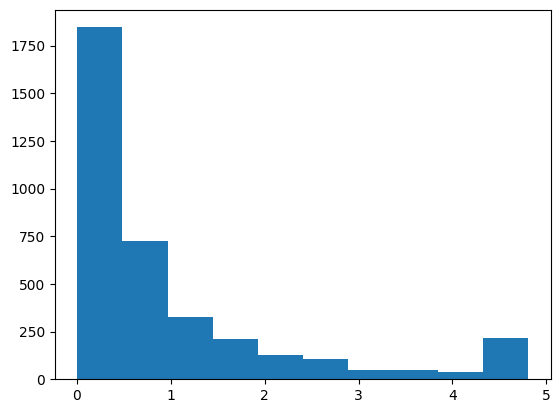

In [137]:
plt.hist(train_weights)

In [138]:
train['DIST_TO_ADM_CENTER'] = np.log1p(train['DIST_TO_ADM_CENTER'])
val['DIST_TO_ADM_CENTER'] = np.log1p(val['DIST_TO_ADM_CENTER'])

In [145]:
features = df_train.columns.values

' target_2 '

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

drop_cols = ['ID', 'month_count', 'SUBFRMT', 'target_1', ' target_2 ']
features = [c for c in train.columns if c not in drop_cols]
cat_features = ['REGION', 'BRANCH', 'CITY', 'subject']
cat_features = [c for c in cat_features if c in features]

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])

X_old = pd.concat([train[features], val[features]], axis=0)
y_old = np.zeros(len(X_old))
X_new = holdout[features]
y_new = np.ones(len(X_new))
X_adv = pd.concat([X_old, X_new], axis=0)
y_adv = np.concatenate([y_old, y_new])

adv_model = CatBoostClassifier(iterations=200, learning_rate=0.05, verbose=0, cat_features=cat_features, random_seed=42)
adv_model.fit(X_adv, y_adv)





train_probs = adv_model.predict_proba(train[features])[:, 1]
train_weights = train_probs / (1 - train_probs + 1e-6)
upper_bound = np.percentile(train_weights, 95)
train_weights = np.clip(train_weights, None, upper_bound)
train_weights = train_weights / np.mean(train_weights)

y_train_log = np.log1p(train[' target_2 '])
y_val_log = np.log1p(val[' target_2 '])

train_pool = Pool(train[features], y_train_log, cat_features=cat_features, weight=train_weights)
val_pool = Pool(val[features], y_val_log, cat_features=cat_features)

reg_model = CatBoostRegressor(
    iterations=2500,
    learning_rate=0.02,
    depth=6,
    loss_function='RMSE',
    eval_metric='MAPE',
    random_seed=42,
    verbose=100
)

reg_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

val_preds = np.expm1(reg_model.predict(val[features]))
print(f"MAPE: {mean_absolute_percentage_error(val[' target_2 '], val_preds)}")

holdout_preds = np.expm1(reg_model.predict(holdout[features]))
pd.DataFrame({'prediction': holdout_preds}).to_csv('predictions.csv', index=False)

0:	learn: 0.0167205	test: 0.0184931	best: 0.0184931 (0)	total: 4.04ms	remaining: 10.1s
100:	learn: 0.0121824	test: 0.0150723	best: 0.0150723 (100)	total: 317ms	remaining: 7.54s
200:	learn: 0.0114355	test: 0.0147423	best: 0.0147423 (200)	total: 634ms	remaining: 7.25s
300:	learn: 0.0111137	test: 0.0146207	best: 0.0146207 (300)	total: 942ms	remaining: 6.88s
400:	learn: 0.0108992	test: 0.0145779	best: 0.0145779 (400)	total: 1.26s	remaining: 6.6s
500:	learn: 0.0107018	test: 0.0145479	best: 0.0145479 (500)	total: 1.61s	remaining: 6.44s
600:	learn: 0.0105043	test: 0.0144996	best: 0.0144989 (599)	total: 1.94s	remaining: 6.14s
700:	learn: 0.0103406	test: 0.0144602	best: 0.0144601 (699)	total: 2.29s	remaining: 5.87s
800:	learn: 0.0101996	test: 0.0144296	best: 0.0144290 (791)	total: 2.6s	remaining: 5.53s
900:	learn: 0.0100773	test: 0.0144008	best: 0.0144005 (899)	total: 2.92s	remaining: 5.18s
1000:	learn: 0.0099519	test: 0.0143723	best: 0.0143723 (994)	total: 3.23s	remaining: 4.84s
1100:	learn: 0


ROC-AUC Adversarial Validation (Drift Score): 0.8887

Топ признаков дрейфа:
                       feature  importance
24  TOTAL_RANK_COMPS_CANNIBALS   26.317559
6         HuffRelativeFamilies   12.562258
17         TRADING_PATCH_SCORE   10.117966
10                    MK_ON_MM    9.310171
4                 TRADE_SQUARE    6.019917
23   HUFF_RANK_COMPS_CANNIBALS    5.653507
14         DENSITY_FAMILY_TYPE    4.658546
49               new_buildings    2.958778
1                       BRANCH    2.588708
3                      subject    2.293074


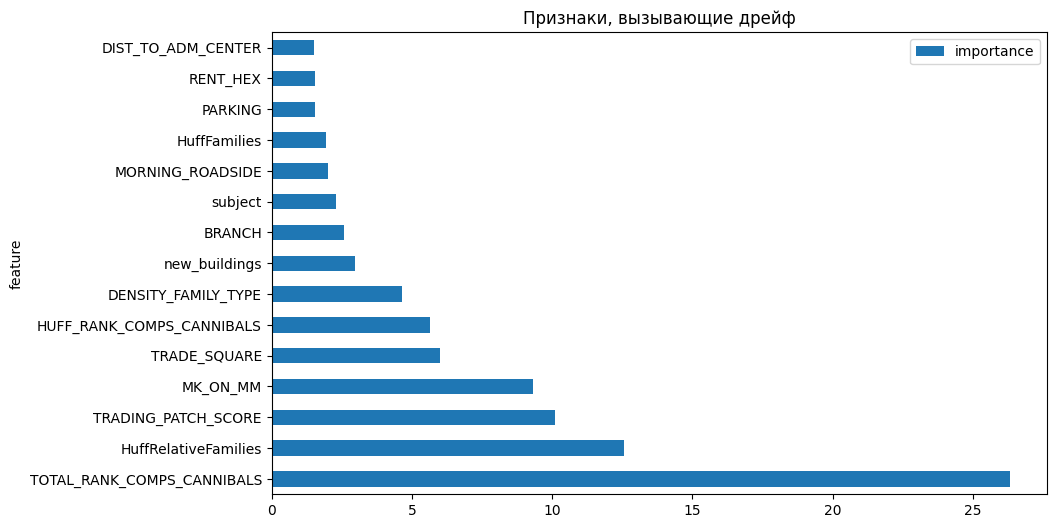

0:	learn: 0.0168215	test: 0.0184716	best: 0.0184716 (0)	total: 4.84ms	remaining: 12.1s
100:	learn: 0.0121585	test: 0.0150514	best: 0.0150514 (100)	total: 333ms	remaining: 7.91s
200:	learn: 0.0114177	test: 0.0147010	best: 0.0147010 (200)	total: 654ms	remaining: 7.47s
300:	learn: 0.0110887	test: 0.0145987	best: 0.0145987 (300)	total: 997ms	remaining: 7.28s
400:	learn: 0.0108626	test: 0.0145286	best: 0.0145282 (399)	total: 1.34s	remaining: 7.04s
500:	learn: 0.0106669	test: 0.0145056	best: 0.0145054 (495)	total: 1.67s	remaining: 6.68s
600:	learn: 0.0104955	test: 0.0144708	best: 0.0144708 (596)	total: 2s	remaining: 6.33s
700:	learn: 0.0103341	test: 0.0144346	best: 0.0144346 (700)	total: 2.33s	remaining: 5.99s
800:	learn: 0.0101857	test: 0.0143944	best: 0.0143944 (800)	total: 2.65s	remaining: 5.62s
900:	learn: 0.0100573	test: 0.0143677	best: 0.0143675 (899)	total: 2.96s	remaining: 5.25s
1000:	learn: 0.0099381	test: 0.0143357	best: 0.0143357 (1000)	total: 3.27s	remaining: 4.89s
1100:	learn: 0

In [164]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

train = pd.read_csv('train.csv')
val = pd.read_csv('val.csv')
holdout = pd.read_csv('holdout.csv')

drop_cols = ['ID', 'month_count', 'SUBFRMT', 'target_1', ' target_2 ']
features = [c for c in train.columns if c not in drop_cols]
cat_features = ['REGION', 'BRANCH', 'CITY', 'subject']
cat_features = [c for c in cat_features if c in features]

for df in [train, val, holdout]:
    df['DIST_TO_ADM_CENTER'] = np.log1p(df['DIST_TO_ADM_CENTER'])

X_old = pd.concat([train[features], val[features]], axis=0)
y_old = np.zeros(len(X_old))
X_new = holdout[features]
y_new = np.ones(len(X_new))

X_adv = pd.concat([X_old, X_new], axis=0)
y_adv = np.concatenate([y_old, y_new])

X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_adv, y_adv, test_size=0.2, stratify=y_adv, random_state=42)

adv_model = CatBoostClassifier(iterations=200, learning_rate=0.05, verbose=0, cat_features=cat_features, random_seed=42)
adv_model.fit(X_a_train, y_a_train, eval_set=(X_a_test, y_a_test))

test_probs = adv_model.predict_proba(X_a_test)[:, 1]
auc = roc_auc_score(y_a_test, test_probs)
print(f"\nROC-AUC Adversarial Validation (Drift Score): {auc:.4f}")

importances = adv_model.get_feature_importance(type='FeatureImportance')
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nТоп признаков дрейфа:")
print(feature_importance_df.head(10))

feature_importance_df.head(15).plot(kind='barh', x='feature', y='importance', figsize=(10, 6))
plt.title('Признаки, вызывающие дрейф')
plt.show()

train_probs = adv_model.predict_proba(train[features])[:, 1]
train_weights = train_probs / (1 - train_probs + 1e-6)
train_weights = np.clip(train_weights, None, np.percentile(train_weights, 95))
train_weights = train_weights / np.mean(train_weights)

y_train_log = np.log1p(train[' target_2 '])
y_val_log = np.log1p(val[' target_2 '])

train_pool = Pool(train[features], y_train_log, cat_features=cat_features, weight=train_weights)
val_pool = Pool(val[features], y_val_log, cat_features=cat_features)

reg_model = CatBoostRegressor(
    iterations=2500,
    learning_rate=0.02,
    depth=6,
    loss_function='RMSE',
    eval_metric='MAPE',
    random_seed=42,
    verbose=100
)

reg_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

val_preds = np.expm1(reg_model.predict(val[features]))
print(f"\nФинальный MAPE на валидации: {mean_absolute_percentage_error(val[' target_2 '], val_preds):.4f}")

holdout_preds = np.expm1(reg_model.predict(holdout[features]))
pd.DataFrame({'prediction': holdout_preds}).to_csv('predictions.csv', index=False)